<a href="https://colab.research.google.com/github/BintangPancahaya/PCVK26_06_BintangPP/blob/main/Week6_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell Identitas
NAMA = 'Bintang Pancahaya P'
NIM  = '244107020115'   # ganti dengan NIM sendiri

print(NAMA, NIM)


Bintang Pancahaya P 244107020115


In [2]:
# Akses file yang terdapat pada drive
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im


In [4]:
def convolution2d(image, kernel, stride, padding):
    img = image.astype(np.float64)
    kh, kw = kernel.shape

    # duplikasi elemen pinggir citra sebanyak 'padding' piksel
    img_pad = cv.copyMakeBorder(img, padding, padding, padding, padding, cv.BORDER_REPLICATE)

    H, W = img.shape
    out_h = (H + 2 * padding - kh) // stride + 1
    out_w = (W + 2 * padding - kw) // stride + 1

    hasil = np.zeros((out_h, out_w))

    for y in range(out_h):
        for x in range(out_w):
            z = 0
            for k1 in range(kh):
                for k2 in range(kw):
                    z = z + kernel[k1, k2] * img_pad[y * stride + k1, x * stride + k2]
            hasil[y, x] = z

    hasil = np.clip(hasil, 0, 255).astype(np.uint8)
    return hasil


In [5]:

img = cv.imread('/content/drive/MyDrive/PCVK/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


In [6]:
# Menentukan kernel yang akan digunakan (kernel untuk filter sharpening)
kernel_sharpen = np.array([[0, -1, 0],
                            [-1, 5, -1],
                            [0, -1, 0]])


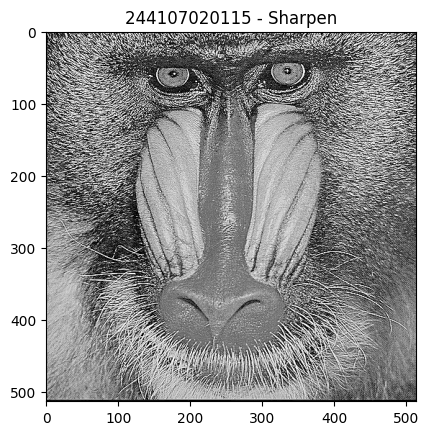

In [7]:
# Memanggil fungsi konvolusi yang telah dibuat sebelumnya, dan menampilkan hasil konvolusinya
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)

plt.imshow(hasil_sharpen, cmap='gray')
plt.title(NIM + ' - Sharpen')
plt.show()


### 3. Image Filter: Average filter, Low Pass Filter, High Pass Filter, dan beberapa filter lainnya

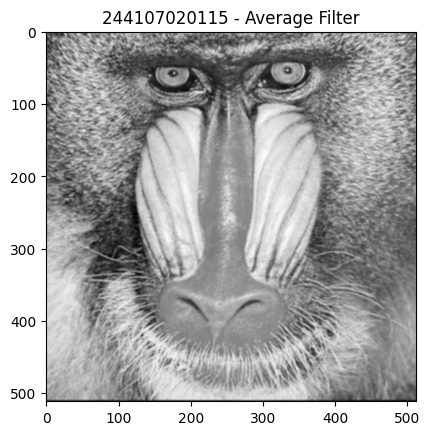

In [8]:
# Filter: Average Filter 3x3
kernel_average = (1/9) * np.array([[1, 1, 1],
                                    [1, 1, 1],
                                    [1, 1, 1]])

hasil_average = convolution2d(img_gray, kernel_average, 1, 1)

plt.imshow(hasil_average, cmap='gray')
plt.title(NIM + ' - Average Filter')
plt.show()


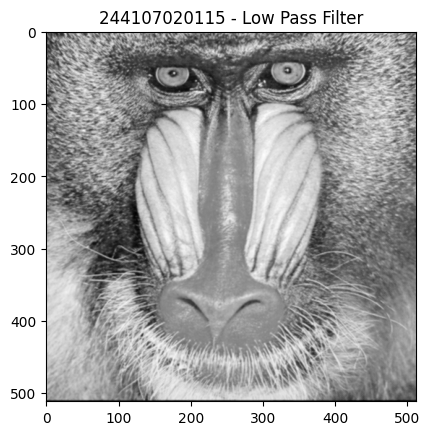

In [9]:
# Filter: Low Pass Filter
kernel_lowpass = (1/12) * np.array([[1, 1, 1],
                                     [1, 4, 1],
                                     [1, 1, 1]])

hasil_lowpass = convolution2d(img_gray, kernel_lowpass, 1, 1)

plt.imshow(hasil_lowpass, cmap='gray')
plt.title(NIM + ' - Low Pass Filter')
plt.show()


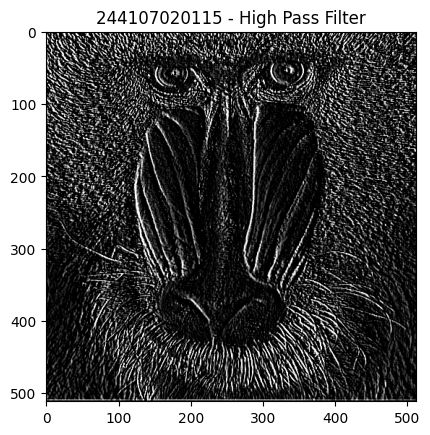

In [10]:
# Filter: High Pass Filter
kernel_highpass = np.array([[-1, 0, 1],
                             [-1, 0, 3],
                             [-3, 0, 1]])

hasil_highpass = convolution2d(img_gray, kernel_highpass, 1, 1)

plt.imshow(hasil_highpass, cmap='gray')
plt.title(NIM + ' - High Pass Filter')
plt.show()


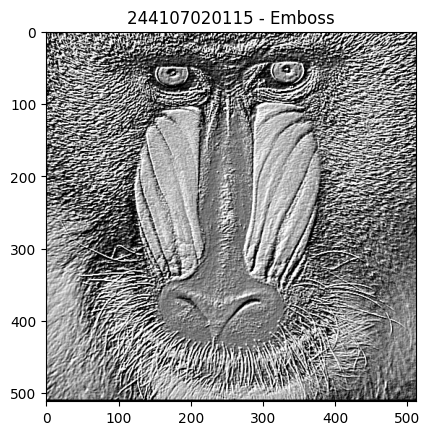

In [11]:
# Filter: Emboss
kernel_emboss = np.array([[-2, -1, 0],
                           [-1,  1, 1],
                           [ 0,  1, 2]])

hasil_emboss = convolution2d(img_gray, kernel_emboss, 1, 1)

plt.imshow(hasil_emboss, cmap='gray')
plt.title(NIM + ' - Emboss')
plt.show()


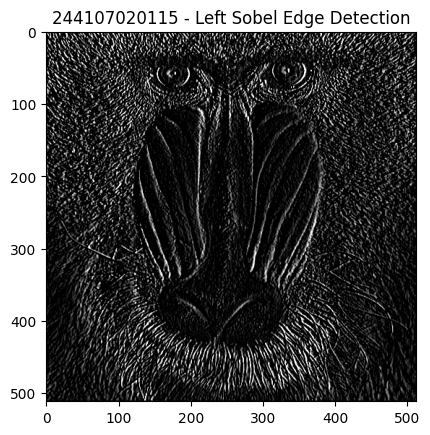

In [12]:
# Filter: Left Sobel Edge Detection
kernel_left_sobel = np.array([[1, 0, -1],
                               [2, 0, -2],
                               [1, 0, -1]])

hasil_left_sobel = convolution2d(img_gray, kernel_left_sobel, 1, 1)

plt.imshow(hasil_left_sobel, cmap='gray')
plt.title(NIM + ' - Left Sobel Edge Detection')
plt.show()


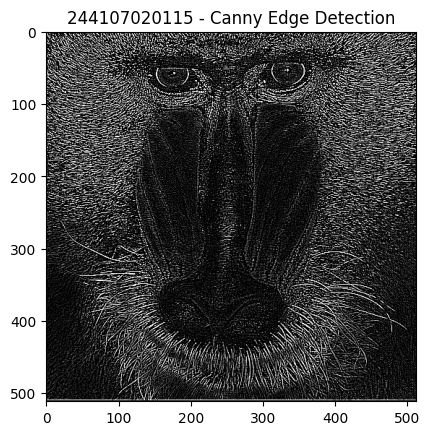

In [13]:
# Filter: Canny Edge Detection (kernel sesuai tabel modul)
kernel_canny = np.array([[-1, -1, -1],
                          [-1,  8, -1],
                          [-1, -1, -1]])

hasil_canny = convolution2d(img_gray, kernel_canny, 1, 1)

plt.imshow(hasil_canny, cmap='gray')
plt.title(NIM + ' - Canny Edge Detection')
plt.show()


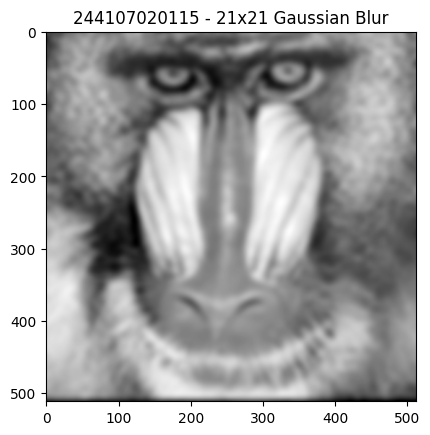

In [14]:
# Filter: 21x21 Gaussian Blur
# Untuk generate kernel gaussian
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

# Catatan: kernel berukuran 21x21 membuat proses konvolusi manual (nested loop) berjalan lebih lama
# dibanding kernel 3x3, karena jumlah perkalian per piksel jauh lebih banyak. Tunggu sampai selesai.
hasil_gaussian21 = convolution2d(img_gray, gauss_kernel, 1, kernel_size // 2)

plt.imshow(hasil_gaussian21, cmap='gray')
plt.title(NIM + ' - 21x21 Gaussian Blur')
plt.show()


## E. FILTER LIBRARY DAN FILTER MODERN
### Percobaan 1

In [15]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()


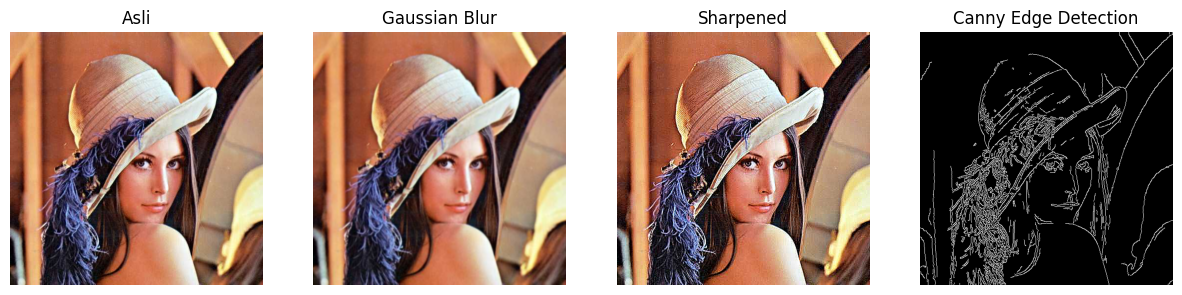

In [16]:
# Percobaan 1 - Gaussian Blur, Sharpen, dan Canny Edge Detection memakai library OpenCV
img = cv.imread("/content/drive/MyDrive/PCVK/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                   ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])


### Percobaan 2

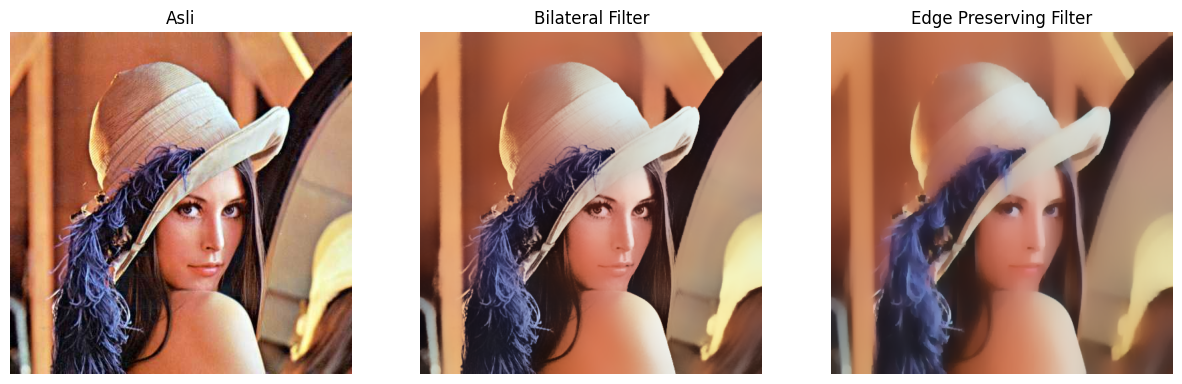

In [17]:

bilateral = cv.bilateralFilter(img, 50, 100, 100)

edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                   ["Asli", "Bilateral Filter", "Edge Preserving Filter"])


### Percobaan 3

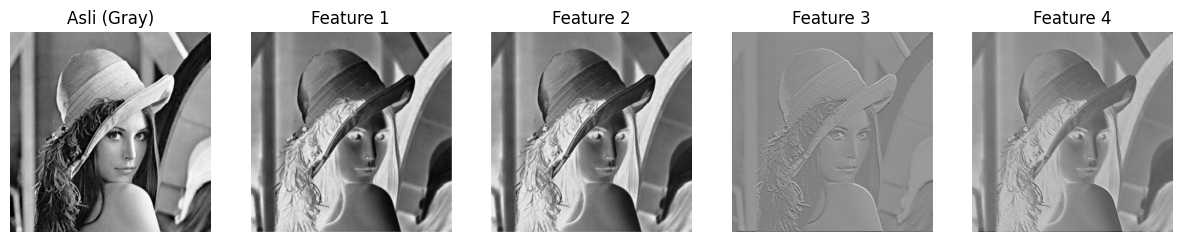

In [18]:
#Filter Feature Map yang digunakan pada CNN, lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])


### Percobaan 4

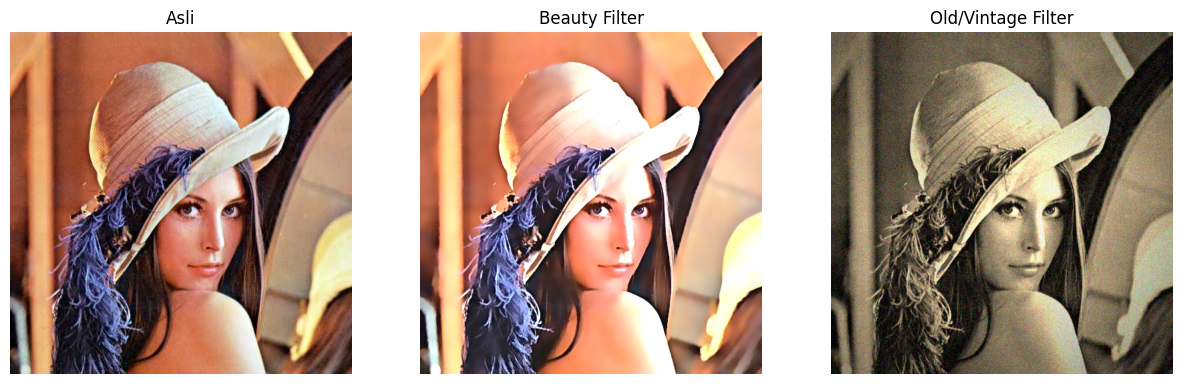

In [19]:
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)


gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

sepia_kernel = np.array([[0.272, 0.534, 0.131],
                          [0.349, 0.686, 0.168],
                          [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])


### Percobaan 5

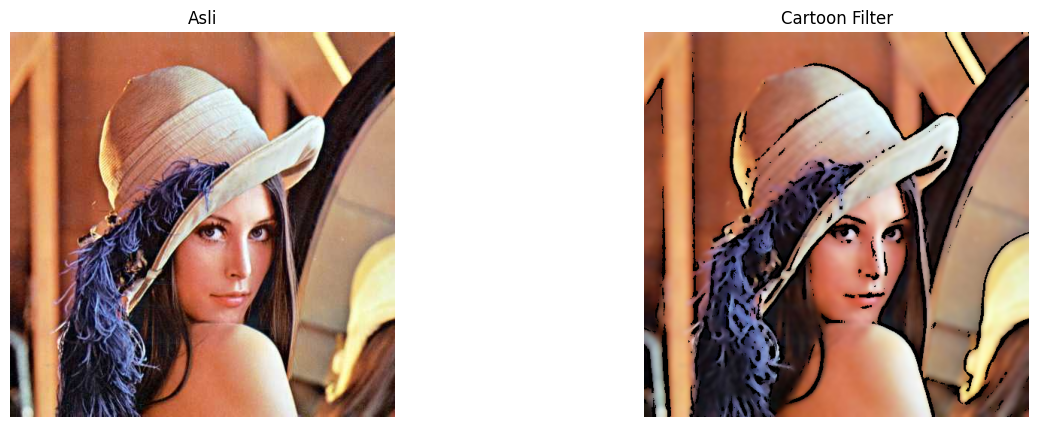

In [20]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                              cv.ADAPTIVE_THRESH_MEAN_C,
                              cv.THRESH_BINARY, 9, 9)

color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])


### Percobaan 6

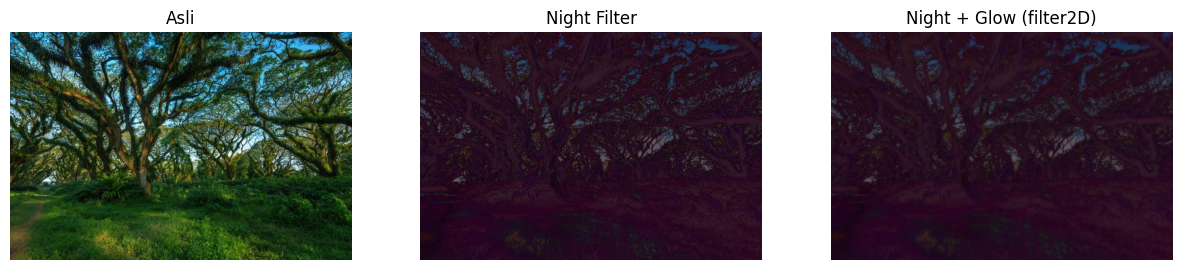

In [21]:
#Night Filter
img = cv.imread("/content/drive/MyDrive/PCVK/djawatan.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                   ["Asli", "Night Filter", "Night + Glow (filter2D)"])


### Percobaan 7

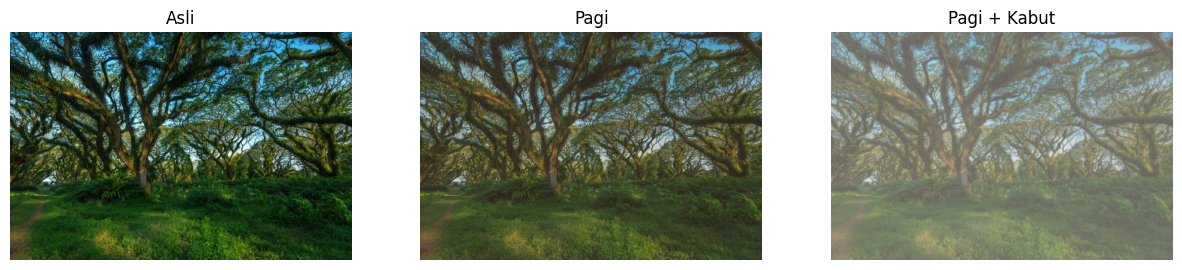

In [22]:

alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                   ["Asli", "Pagi", "Pagi + Kabut"])


## TUGAS PRAKTIKUM
### 1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise "Salt and Pepper"

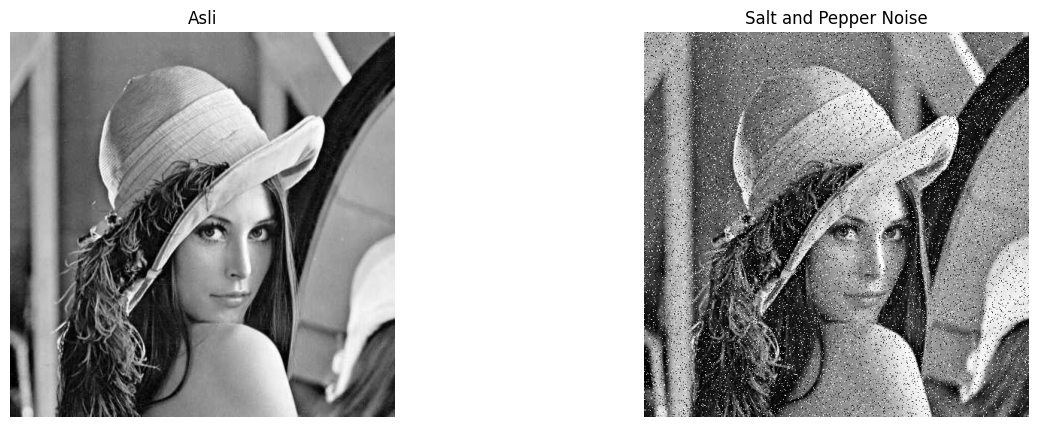

In [24]:
# 1a - Tambahkan noise Salt and Pepper ke citra keabuan (lena.jpg)
gray = cv.imread("/content/drive/MyDrive/PCVK/lena.jpg", cv.IMREAD_GRAYSCALE)

noisy = gray.copy()
jumlah_noise = int(0.05 * gray.size)   # 5% piksel citra kena noise

# noise 'garam' (bintik putih)
ys = np.random.randint(0, gray.shape[0], jumlah_noise)
xs = np.random.randint(0, gray.shape[1], jumlah_noise)
noisy[ys, xs] = 255

# noise 'lada' (bintik hitam)
ys = np.random.randint(0, gray.shape[0], jumlah_noise)
xs = np.random.randint(0, gray.shape[1], jumlah_noise)
noisy[ys, xs] = 0

show_side_by_side([gray, noisy], ["Asli", "Salt and Pepper Noise"])


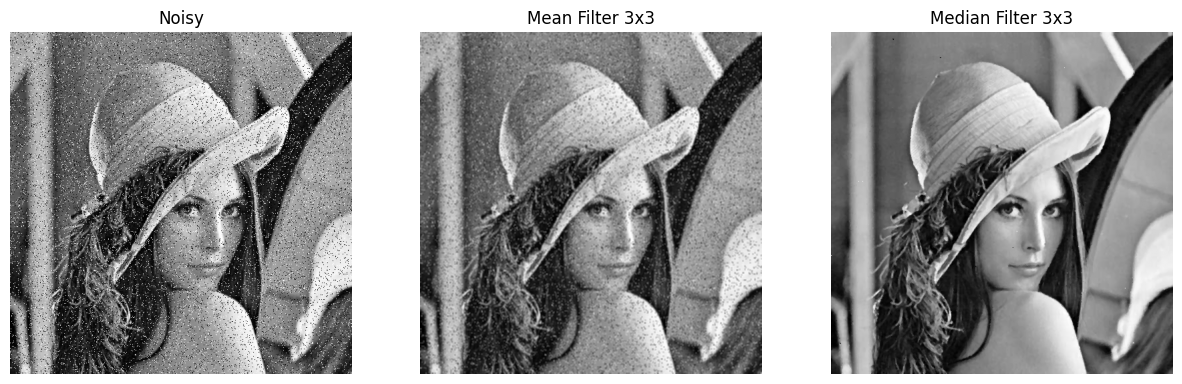

In [25]:
# 1b - Terapkan Mean Filter (3x3) dan Median Filter (3x3)
mean_filtered = cv.blur(noisy, (3, 3))
median_filtered = cv.medianBlur(noisy, 3)

show_side_by_side([noisy, mean_filtered, median_filtered],
                   ["Noisy", "Mean Filter 3x3", "Median Filter 3x3"])


**1c - Jawaban:**
Mean filter menghitung rata-rata seluruh piksel dalam jendela 3×3, termasuk piksel noise
(nilai 0 atau 255) yang ekstrem. Karena nilai ekstrem ini ikut dirata-ratakan, noise tidak
hilang sepenuhnya ia hanya "disebar" tipis-tipis ke piksel tetangganya, sehingga citra
menjadi blur namun bekas noise masih terlihat sebagai bercak pudar.

Median filter, sebaliknya, mengambil **nilai tengah (median)** dari seluruh piksel dalam
jendela, bukan rata-ratanya. Nilai piksel noise (0 atau 255) hampir selalu menjadi nilai
ekstrem/outlier dalam jendela, sehingga saat diurutkan berada di ujung dan tidak pernah
terpilih sebagai median (kecuali jumlah noise dalam satu jendela sangat banyak).

### 2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)


In [26]:
# 2a - Buat kernel penajaman (Sharpening Kernel) ukuran 3x3 dan 5x5
kernel_sharpen_3x3 = np.array([[0, -1, 0],
                                [-1, 5, -1],
                                [0, -1, 0]])

kernel_sharpen_5x5 = np.array([[-1, -1, -1, -1, -1],
                                [-1,  2,  2,  2, -1],
                                [-1,  2,  8,  2, -1],
                                [-1,  2,  2,  2, -1],
                                [-1, -1, -1, -1, -1]]) / 8

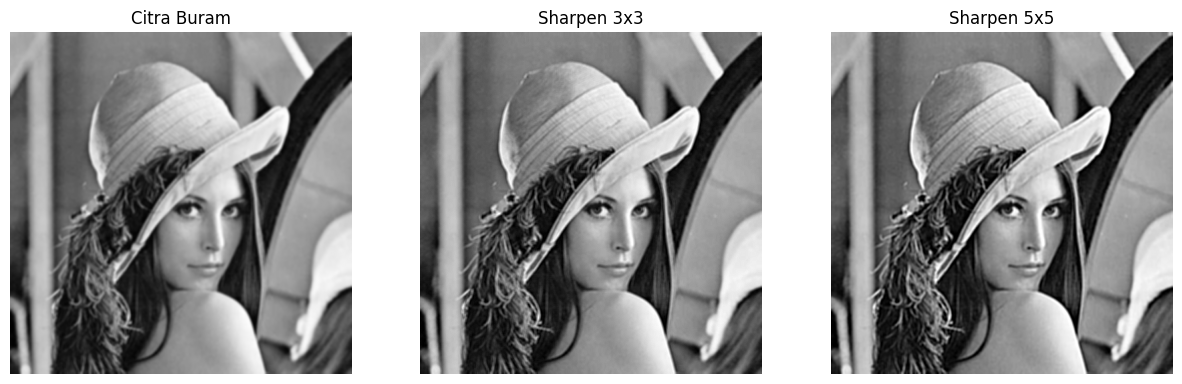

In [27]:
# 2b - Terapkan pada citra yang sedikit buram (blurry)
img_blurry = cv.GaussianBlur(gray, (5, 5), 2)

hasil_3x3 = cv.filter2D(img_blurry, -1, kernel_sharpen_3x3)
hasil_5x5 = cv.filter2D(img_blurry, -1, kernel_sharpen_5x5)

show_side_by_side([img_blurry, hasil_3x3, hasil_5x5],
                   ["Citra Buram", "Sharpen 3x3", "Sharpen 5x5"])


**2c - Jawaban:**
Kernel 3×3 hanya melibatkan piksel tetangga terdekat, sehingga penajaman yang dihasilkan
lebih halus dan natural tepi menjadi lebih jelas tanpa distorsi berlebihan, tetapi untuk
citra yang sangat buram efeknya kadang terasa kurang kuat.

Kernel 5×5 melibatkan area piksel yang lebih luas, sehingga penajamannya lebih agresif dan
tepi terlihat lebih tegas. Namun karena bobot koefisiennya lebih besar dan mencakup lebih
banyak piksel, noise di sekitar tepi juga lebih menonjol dibanding kernel 3×3.

**Kesimpulan:** untuk penggunaan sehari-hari, kernel **3×3** lebih optimal karena hasilnya
lebih natural dengan distorsi noise yang minim. Kernel 5×5 baru layak dipakai bila citra
memang sangat buram dan penajaman kuat lebih dibutuhkan daripada kehalusan visual.


### 3. Tugas Kreasi: Filter Kartun Sederhana

In [30]:
# 3a - Fungsi kustom kartun(image): Bilateral Filter + Canny Edge + operasi logika (versi lain)
def kartun(image):
    gray_img = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray_img, 5)

    # Deteksi garis tepi menggunakan Canny Edge
    tepi = cv.Canny(gray_blur, 80, 150)
    tepi = cv.bitwise_not(tepi)   # dibalik: garis tepi jadi hitam, latar jadi putih (mask)

    # Penghalusan warna menggunakan Bilateral Filter
    warna = cv.bilateralFilter(image, d=7, sigmaColor=150, sigmaSpace=150)

    # Penggabungan (kombinasi) keduanya menggunakan operasi logika (bitwise_and)
    hasil = cv.bitwise_and(warna, warna, mask=tepi)
    return hasil

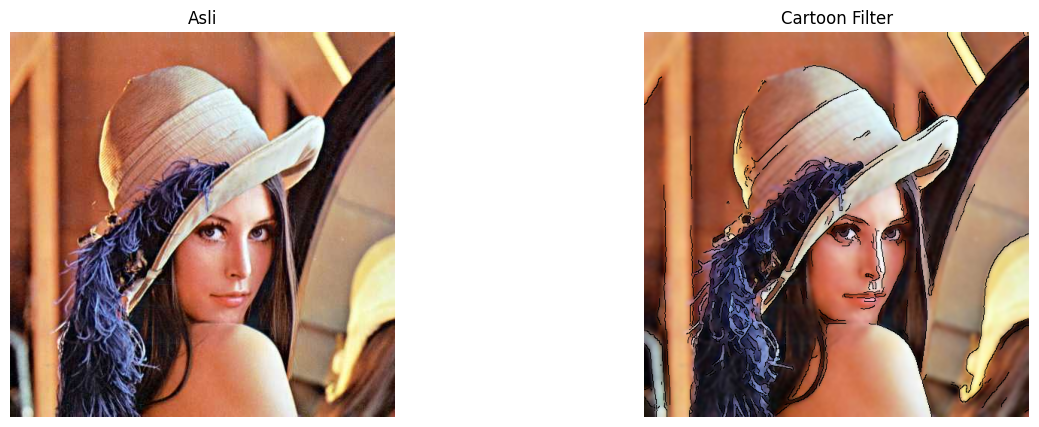

In [31]:
# 3b - Tampilkan hasil citra asli dengan citra efek kartun bersebelahan
img_tugas3 = cv.imread("/content/drive/MyDrive/PCVK/lena.jpg")
hasil_kartun = kartun(img_tugas3)

show_side_by_side([img_tugas3, hasil_kartun], ["Asli", "Cartoon Filter"])
